# Data Quality Assessment Notebook

In [1]:
# These lines bring in helpful tools (libraries) for working with data.
# 'pandas' is great for tables (like spreadsheets).
# 'numpy' helps with numbers and calculations.
# 're' is for finding patterns in text.
# 'datetime', 'timezone', 'timedelta' help with dates and times.
import pandas as pd
import numpy as np
import re
from datetime import datetime, timezone, timedelta

## Load Data and Initial Inspection
Here, we load the video events data from a CSV file into a pandas DataFrame. We then display the first few rows and get a summary of the data (like column names, data types, and missing values) to understand its basic structure.

In [2]:
# We're loading our data from a CSV file (like an Excel file) into something called a DataFrame, which is a table in Python.
df = pd.read_csv("/content/video_events_sample.csv")

# This shows us the first few rows of our data, so we can get a quick look at what's inside.
df.head()

,event_id,event_type,session_id,platform,content_id,timestamp,duration_ms,device_id,firmware_version,error_code
0,a3a65b03-93ce-414f-a817-ac9e9f4cebe2,buffer_start,2f0b1436-8697-41f1-a288-c0d8fcb512e6,roku,content_0044,2026-05-01T12:15:48Z,NaN,device_1ab1a062,12.1.3,NaN
1,eb102904-b330-4e52-9ef4-b579c9fd732b,buffer_end,3ae631c7-9378-4467-8d8b-418f043e2e1f,specguide,content_0043,2026-04-29T06:05:12Z,3970996.0,device_b7e611e0,11.5.1,NaN
2,9f3342e6-e410-4df5-8b32-d6d589a3c3b2,error,7d75f6da-c30a-47cc-8cf6-abf4ff329b57,roku,content_0008,2026-04-23T07:19:53Z,1310.0,device_85682196,11.4.0,E007
3,b97aa32c-f4d7-4e13-adaf-4fe2919d9f6a,buffer_end,7d75f6da-c30a-47cc-8cf6-abf4ff329b57,roku,content_0028,2026-05-04T07:18:35Z,3812736.0,device_55afa587,12.1.3,NaN
4,174342a8-187f-4e44-bd91-786397d3335e,playback_start,91ca5769-55df-4f3f-bf66-5ed1ebf0f5fe,specguide,content_0048,2026-05-05T18:55:55Z,NaN,device_6c9abf2a,12.2.0,NaN


## Setup and Initial Definitions
This section imports necessary Python libraries and defines lists of valid values for later data quality checks. It also initializes an empty list to store any data quality issues found. This part of the notebook defines `valid_event_types`, `valid_platforms`, `valid_error_codes`, and the `findings` list. It also defines `add_issue` to standardize how findings are added.

In [3]:
# These lines tell us how many rows (entries) and columns (categories) our data table has.
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# This gives us a summary of our data, like what kind of information is in each column and if there are any missing pieces.
df.info()

Rows: 1000
Columns: ['event_id', 'event_type', 'session_id', 'platform', 'content_id', 'timestamp', 'duration_ms', 'device_id', 'firmware_version', 'error_code']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_id          1000 non-null   object 
 1   event_type        1000 non-null   object 
 2   session_id        1000 non-null   object 
 3   platform          1000 non-null   object 
 4   content_id        973 non-null    object 
 5   timestamp         1000 non-null   object 
 6   duration_ms       626 non-null    float64
 7   device_id         995 non-null    object 
 8   firmware_version  999 non-null    object 
 9   error_code        214 non-null    object 
dtypes: float64(1), object(9)
memory usage: 78.3+ KB


## Helper Function to Record Issues
This small mini-program (a function) helps us consistently record any data quality problems we find. It stores details about the problem, its severity, and where it occurred in the data.

In [4]:
# Here we're defining lists of 'correct' or 'allowed' values for certain columns.
# These help us check if the data has unexpected entries.
valid_event_types = ["playback_start", "playback_end", "buffer_start", "buffer_end", "error"]
valid_platforms = ["roku", "stva", "specguide", "odn", "tve"]
valid_error_codes = [f"E{str(i).zfill(3)}" for i in range(1, 11)]

# This is an empty list where we will store all the 'findings' or issues we discover in our data.
findings = []

## Data Quality Checks - Part 1: Basic Structure and Content
In this section, we start checking our data for common issues. We look for missing required columns, duplicate records, and invalid values in key fields like `event_type` and `platform`. We also check if important identifiers like `content_id` and `device_id` are present, and if `firmware_version` follows the expected format.

In [5]:
# This is a special mini-program (a function) that helps us record any problems we find.
# It takes details about the problem (like its name, how serious it is, and which rows are affected) and adds them to our 'findings' list.
def add_issue(rule_name, severity, issue_type, rows):
    for idx in rows:
        findings.append({
            "row_number": idx,
            "rule_name": rule_name,
            "severity": severity,
            "issue_type": issue_type,
            "event_id": df.loc[idx, "event_id"] if "event_id" in df.columns else None,
            "session_id": df.loc[idx, "session_id"] if "session_id" in df.columns else None
        })

## Data Quality Checks - Part 1: Required Columns
This cell defines the `required_columns` list and checks if any of these essential columns are missing from our DataFrame. This is a foundational check to ensure the dataset has all the expected fields.

In [6]:
# This is a list of all the columns that we expect to be in our data table.
required_columns = [
    "event_id", "event_type", "session_id", "platform", "content_id",
    "timestamp", "duration_ms", "device_id", "firmware_version", "error_code"
]

# We check if any of these important columns are missing from our actual data table.
missing_columns = [col for col in required_columns if col not in df.columns]

# This will show us if any required columns are indeed missing.
missing_columns

[]

## Data Quality Checks - Part 1: Common Issues
This cell performs several checks for common data quality issues: duplicate event IDs, invalid event types and platforms (compared to predefined valid lists), missing `content_id` and `device_id`, and incorrectly formatted `firmware_version`. Each identified issue is logged using the `add_issue` function.

In [7]:
# Now we're checking our data for various quality issues, one by one.

# 1. Duplicate event_id: We look for rows where the 'event_id' is repeated, which means we might have duplicate records.
duplicate_rows = df[df["event_id"].duplicated(keep=False)].index
add_issue("Duplicate event_id", "HIGH", "Duplicate record", duplicate_rows)

# 2. Invalid event_type: We check if the 'event_type' column has values that are not in our list of 'valid_event_types'.
invalid_event_type_rows = df[~df["event_type"].isin(valid_event_types)].index
add_issue("Invalid event_type", "HIGH", "Invalid value", invalid_event_type_rows)

# 3. Invalid platform: We check if the 'platform' column has values that are not in our list of 'valid_platforms'.
invalid_platform_rows = df[~df["platform"].isin(valid_platforms)].index
add_issue("Invalid platform", "MEDIUM", "Invalid value", invalid_platform_rows)

# 4. Missing content_id: We find rows where the 'content_id' is empty or just spaces.
missing_content_rows = df[df["content_id"].isna() | (df["content_id"].astype(str).str.strip() == "")].index
add_issue("Missing content_id", "HIGH", "Missing value", missing_content_rows)

# 5. Missing device_id: We find rows where the 'device_id' is empty or just spaces.
missing_device_rows = df[df["device_id"].isna() | (df["device_id"].astype(str).str.strip() == "")].index
add_issue("Missing device_id", "HIGH", "Missing value", missing_device_rows)

# 6. Firmware version format X.Y.Z: We check if the 'firmware_version' follows a specific pattern (like 1.2.3).
firmware_pattern = r"^\d+\.\d+\.\d+$"
invalid_firmware_rows = df[
    df["firmware_version"].isna() |
    ~df["firmware_version"].astype(str).str.match(firmware_pattern)
].index
add_issue("Invalid firmware_version format", "MEDIUM", "Format issue", invalid_firmware_rows)

## Data Quality Checks - Part 2: Timestamp Validity
This part focuses on the quality of timestamp data. It converts the 'timestamp' column to a proper datetime format, identifying and logging any parsing errors. It also checks if timestamps fall within a reasonable recent period (e.g., the last 30 days) and records any that are outside this window.

In [8]:
# We try to turn the 'timestamp' column into a proper date and time format. If it can't be converted, it becomes 'NaT' (Not a Time).
df["parsed_timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

# We identify rows where the timestamp couldn't be correctly understood.
invalid_timestamp_rows = df[df["parsed_timestamp"].isna()].index
add_issue("Invalid timestamp format", "HIGH", "Timestamp issue", invalid_timestamp_rows)

# We set a time window: the current time and 30 days before that.
latest_allowed = pd.Timestamp.now(tz="UTC")
earliest_allowed = latest_allowed - pd.Timedelta(days=30)

# We find rows where the timestamp is outside this 30-day window (either too old or in the future).
outside_30_days_rows = df[
    df["parsed_timestamp"].notna() &
    ((df["parsed_timestamp"] < earliest_allowed) | (df["parsed_timestamp"] > latest_allowed))
].index

# We record these timestamps that are outside the allowed range.
add_issue("Timestamp outside last 30 days", "MEDIUM", "Timestamp issue", outside_30_days_rows)

## Data Quality Checks - Part 2: Duration Consistency
This cell validates the `duration_ms` field. It checks for negative durations and enforces business rules: `duration_ms` should be null for start events (`playback_start`, `buffer_start`) and non-null for end events (`playback_end`, `buffer_end`). All deviations are logged as issues.

In [9]:
# We convert the 'duration_ms' column to numbers. If it can't be converted, it becomes 'NaN' (Not a Number).
df["duration_ms_numeric"] = pd.to_numeric(df["duration_ms"], errors="coerce")

# We check for durations that are negative, which usually doesn't make sense for time.
negative_duration_rows = df[df["duration_ms_numeric"] < 0].index
add_issue("Negative duration_ms", "HIGH", "Invalid value", negative_duration_rows)

# These are event types that mark the *start* of something.
start_events = ["playback_start", "buffer_start"]

# For 'start' events, duration usually shouldn't be recorded. We find rows where a duration *is* present for these events.
duration_present_for_start_rows = df[
    df["event_type"].isin(start_events) &
    df["duration_ms"].notna()
].index

# We record this as an issue, as duration should typically be null for start events.
add_issue("duration_ms should be null for start events", "MEDIUM", "Business rule issue", duration_present_for_start_rows)

# These are event types that mark the *end* of something.
end_events = ["playback_end", "buffer_end"]

# For 'end' events, duration *should* be recorded. We find rows where duration is missing for these events.
missing_duration_for_end_rows = df[
    df["event_type"].isin(end_events) &
    df["duration_ms"].isna()
].index

# We record this as an issue, as duration should be present for end events.
add_issue("duration_ms missing for end events", "MEDIUM", "Business rule issue", missing_duration_for_end_rows)

## Data Quality Checks - Part 3: Error Code Logic
Here, we specifically check the `error_code` field for consistency. It ensures that an `error_code` is present and valid (from our predefined list) only when the `event_type` is 'error'. Conversely, it flags if an `error_code` is present for non-error events.

In [10]:
# We check if 'error' events have an 'error_code' that isn't in our list of 'valid_error_codes'.
error_code_invalid_rows = df[
    (df["event_type"] == "error") &
    (~df["error_code"].isin(valid_error_codes))
].index

# We record 'error' events with an invalid error code.
add_issue("Invalid error_code for error event", "HIGH", "Invalid value", error_code_invalid_rows)

# We check if non-error events surprisingly have an 'error_code' present.
error_code_present_non_error_rows = df[
    (df["event_type"] != "error") &
    (df["error_code"].notna())
].index

# We record cases where an error code appears when it shouldn't.
add_issue("error_code present for non-error event", "MEDIUM", "Business rule issue", error_code_present_non_error_rows)

## Summarizing Data Quality Findings - Detailed Table
After running all the checks, this cell compiles all the individual issues recorded in the `findings` list into a structured pandas DataFrame called `findings_df`. This table provides a detailed, row-level view of every data quality issue found.

In [11]:
# We take all the 'findings' we collected and turn them into a new DataFrame (table) called 'findings_df'.
findings_df = pd.DataFrame(findings)

# We show the first few rows of our 'findings_df' to see all the detected issues.
findings_df.head()

,row_number,rule_name,severity,issue_type,event_id,session_id
0,0,Duplicate event_id,HIGH,Duplicate record,a3a65b03-93ce-414f-a817-ac9e9f4cebe2,2f0b1436-8697-41f1-a288-c0d8fcb512e6
1,3,Duplicate event_id,HIGH,Duplicate record,b97aa32c-f4d7-4e13-adaf-4fe2919d9f6a,7d75f6da-c30a-47cc-8cf6-abf4ff329b57
2,24,Duplicate event_id,HIGH,Duplicate record,b97aa32c-f4d7-4e13-adaf-4fe2919d9f6a,7d75f6da-c30a-47cc-8cf6-abf4ff329b57
3,29,Duplicate event_id,HIGH,Duplicate record,856e356e-84d1-4c2e-a7f9-af6ce2264338,1f2eae4b-d609-4d6d-aca7-1ac11f814278
4,51,Duplicate event_id,HIGH,Duplicate record,e831fae4-51a0-469e-a7c6-23e3d929ca75,11deaa9c-7892-4cc5-9483-7f2f02ccc096


## Summarizing Data Quality Findings - Summary Report
This cell processes the detailed `findings_df` to create a `summary_df`. This summary table groups issues by `rule_name`, `severity`, and `issue_type`, counts their occurrences (`issue_count`), and then sorts them to quickly highlight the most frequent problems.

In [12]:
# We create a summary table ('summary_df') that counts how many times each type of issue appeared.
# It groups the issues by their name, severity, and type, and then counts them.
# Finally, it sorts them from the most common issue to the least common.
summary_df = (
    findings_df
    .groupby(["rule_name", "severity", "issue_type"])
    .size()
    .reset_index(name="issue_count")
    .sort_values("issue_count", ascending=False)
)

# We display the summary table to see the overview of all data quality issues.
summary_df

,rule_name,severity,issue_type,issue_count
6,Timestamp outside last 30 days,MEDIUM,Timestamp issue,988
0,Duplicate event_id,HIGH,Duplicate record,88
3,Missing content_id,HIGH,Missing value,27
5,Negative duration_ms,HIGH,Invalid value,20
8,error_code present for non-error event,MEDIUM,Business rule issue,15
7,duration_ms should be null for start events,MEDIUM,Business rule issue,9
1,Invalid error_code for error event,HIGH,Invalid value,8
2,Invalid firmware_version format,MEDIUM,Format issue,6
4,Missing device_id,HIGH,Missing value,5


## Exporting Data Quality Reports
Finally, we save the detailed `findings_df` (row-level data quality findings) and the `summary_df` (overall data quality summary) into separate CSV files. These files can be used for further analysis or reporting.

In [13]:
# We save our detailed list of findings to a CSV file.
findings_df.to_csv("row_level_data_quality_findings.csv", index=False)
# We save our summary report to another CSV file.
summary_df.to_csv("data_quality_summary_report.csv", index=False)

# A message to confirm that the files have been saved.
print("Files created successfully!")

Files created successfully!


## Downloading Reports
This section provides a convenient way to download the generated CSV reports directly to your local computer from Google Colab, allowing you to easily access and share the results.

In [18]:
# This line imports a tool that lets us download files from this environment.
from google.colab import files

# These lines download the two CSV files we just created to your computer.
files.download("row_level_data_quality_findings.csv")
files.download("data_quality_summary_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Data Quality Overview
This cell provides a quick overview of the data quality assessment results. It displays the total number of rows checked, the total count of all data quality issues found, and the `summary_df` table, which lists issues by frequency.

In [15]:
print("Total rows checked:", len(df))
print("Total data quality issues found:", len(findings_df))
display(summary_df)

Total rows checked: 1000
Total data quality issues found: 1166


,rule_name,severity,issue_type,issue_count
6,Timestamp outside last 30 days,MEDIUM,Timestamp issue,988
0,Duplicate event_id,HIGH,Duplicate record,88
3,Missing content_id,HIGH,Missing value,27
5,Negative duration_ms,HIGH,Invalid value,20
8,error_code present for non-error event,MEDIUM,Business rule issue,15
7,duration_ms should be null for start events,MEDIUM,Business rule issue,9
1,Invalid error_code for error event,HIGH,Invalid value,8
2,Invalid firmware_version format,MEDIUM,Format issue,6
4,Missing device_id,HIGH,Missing value,5


## Visualizing Data Quality Issues
This section generates a bar chart using `matplotlib` to visually represent the `issue_count` for each `rule_name` from the `summary_df`. This visualization helps to quickly identify which data quality rules are flagging the most problems in the dataset.

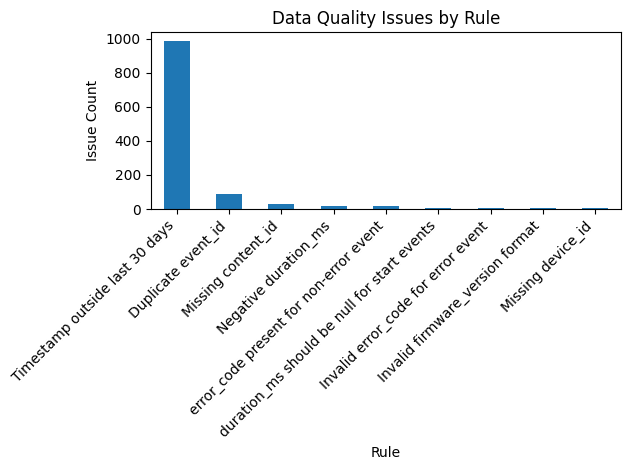

In [16]:
import matplotlib.pyplot as plt

summary_df.plot(kind="bar", x="rule_name", y="issue_count", legend=False)
plt.title("Data Quality Issues by Rule")
plt.xlabel("Rule")
plt.ylabel("Issue Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()